# What is feature engineering

feature engineering is the process of creating, transforming and modifying raw data into useful features that can be given to a machine learning model to improve its performance.

<!-- # what is feature -->
A feature is an individual measureable property or characteristic of a data record that is used as input to a machine learning model.

House Dateset:
1. Area          ---> Feature
2. Bedrooms      ---> Feature
3. Bathrooms     ---> Feature
4. Location      ---> Feature
5. Age           ---> Feature
6. Price         ---> Target

## why need feature engineering
--> Raw data is often not in the best form for machine learning Eg., Date of Birth 2000-05-15

A model may not directly benefit from the raw data,  We can extarct:

1. Age
2. Birth Month
3. Birth Year
4. Birth Day


In [37]:
import pandas as pd 

data = pd.read_csv("C:/Users/abhijit/Downloads/archive/Titanic-Dataset.csv")

In [38]:
import numpy as np

In [39]:
df = pd.DataFrame(data)

In [40]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [41]:
print(df["SibSp"])

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: SibSp, Length: 891, dtype: int64


# Creating New Features

In [42]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print (df["FamilySize"])

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: FamilySize, Length: 891, dtype: int64


In [43]:
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)
print (df["IsAlone"])

0      0
1      0
2      1
3      0
4      1
      ..
886    1
887    1
888    0
889    1
890    1
Name: IsAlone, Length: 891, dtype: int64


# Handling Missing Values

instead of simply  deleting all rows with missing values, we can replace the missing values with median age 

In [44]:
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)


In [45]:
print(df["Age"].isnull().sum())

0


In [46]:
# missing embarked
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [47]:
# suppose s is the most common value
df["Embarked"] = df["Embarked"].fillna("S")


In [48]:
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [49]:
# cabin usually contains many missing values
print(df["Cabin"].isnull().sum())

687


In [50]:
# insted of trying to guess the exact cabi number we can create a new feature

df["Has Cabin"] = df["Cabin"].notnull().astype(int)
print(df["Has Cabin"])

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Has Cabin, Length: 891, dtype: int64


In [51]:
# now remove the original column if isn't neededt not needed

df.drop("Cabin", axis = 1, inplace = True)

In [56]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'IsAlone',
       'Has Cabin'],
      dtype='str')


# Extracting Information

In [57]:
# the name column contaonis useful information such as:
# mr, mrs, miss, master

df["Title"] = df["Name"].str.extract(r',\s*([^.]*)\.')

df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [58]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [59]:
df["Title"] = df["Title"].replace(
    {"Mlle" : "Miss",
    "MS" : "Miss",
    "Mme" : "Mrs"
    }
)

In [60]:
df["Title"].value_counts()

Title
Mr              517
Miss            184
Mrs             126
Master           40
Dr                7
Rev               6
Major             2
Col               2
Don               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

# Encoding Categorical Features

In [61]:
df["Sex"] = df["Sex"].map({
    "male" : 0,
    "female" : 1
})

In [62]:
df = pd.get_dummies(df, columns = ["Embarked"],drop_first = True)

In [63]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'FamilySize', 'IsAlone', 'Has Cabin',
       'Title', 'Embarked_Q', 'Embarked_S'],
      dtype='str')


In [64]:
df.drop(["PassengerId", "Name", "Ticket"], axis = 1, inplace = True)

In [65]:
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Has Cabin', 'Title', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

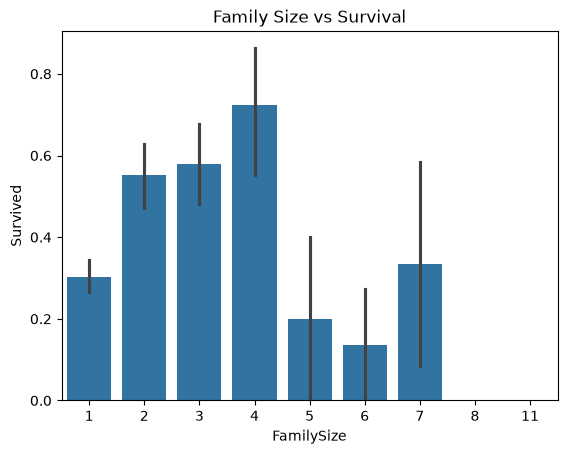

In [68]:
sns.barplot(data = df, x = "FamilySize", y = "Survived")
plt.title("Family Size vs Survival")
plt.show()